
# Naive Bayes for Text Classification - CS313 Group Project

**Group:** Nguyen Hoang Xuan Bach · Bui Dien Gia Bao · Le Gia Bao · Nguyen Thai Bao · Bui Huy Chuong · Tran Anh Duong · Do Quang Duy


## Datasets

| # | Dataset | Task | Source | Size |
|---|---|---|---|---|
| DS1 | SMS Spam Collection | `ham` / `spam` | UCI ML Repository, id 228 | 5,574 messages |
| DS2 | IMDb Sentiment | `pos` / `neg` | Maas et al. 2011 (ACL), `aclImdb_v1` | 25,000 train / 25,000 test |



## 1 - Environment


In [1]:
# Step 1 - imports and environment
import gc
import io
import json
import re
import sys
import tarfile
import time
import zipfile
from pathlib import Path
from urllib.request import urlretrieve

import joblib
import numpy as np
import pandas as pd
import sklearn
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, brier_score_loss, classification_report,
                             confusion_matrix, f1_score, precision_score, recall_score,
                             roc_auc_score)
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.naive_bayes import BernoulliNB, ComplementNB, MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.utils.class_weight import compute_sample_weight

import matplotlib.pyplot as plt

BASE = Path.cwd()
if not (BASE / "pyproject.toml").exists() and (BASE.parent / "pyproject.toml").exists():
    BASE = BASE.parent
DATA = BASE / "data"
DATA_RAW = DATA / "raw"
MODELS = BASE / "models"
REPORTS = BASE / "reports"
DOCS = BASE / "docs"
for p in (DATA, DATA_RAW, MODELS, REPORTS, DOCS):
    p.mkdir(parents=True, exist_ok=True)

print("python      :", sys.version.split()[0])
print("scikit-learn:", sklearn.__version__)
print("pandas      :", pd.__version__)
print("numpy       :", np.__version__)
print("joblib      :", joblib.__version__)
print("working dir :", BASE)


python      : 3.13.3
scikit-learn: 1.7.2
pandas      : 2.3.3
numpy       : 2.2.6
joblib      : 1.5.2
working dir : D:\UIT\CS313


## 2 - Configuration

In [2]:
# Step 2 - configuration. Change the model here, everything downstream follows.
SEED = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.15      # carved out of TRAIN only, used to pick the decision threshold

TASKS = {
    "sms": {
        "csv": DATA_RAW / "sms_spam.csv",
        "text_col": "message",
        "label_col": "label",
        "classes": ["ham", "spam"],
        "positive": "spam",            # the class that actually matters
        "use_official_split": False,
        "short": "SMS Spam",   # SMS has no official split -> stratified split
    },
    "imdb": {
        "csv": DATA_RAW / "imdb_reviews.csv",
        "text_col": "text",
        "label_col": "label",
        "classes": ["neg", "pos"],
        "positive": "pos",
        "use_official_split": True,
        "short": "IMDb Sentiment",    # IMDb ships train/test -> use it as-is
    },
}
# Cross-validation folds and timing repeats, kept here so a change in one
# place cannot silently leave the other implementation measuring something
# different.
CV_FOLDS = 5
TIMING_REPS = 200

ALPHAS = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]

np.random.seed(SEED)
for name, cfg in TASKS.items():
    print(f"{name:5s} -> positive={cfg['positive']!r}  official_split={cfg['use_official_split']}")


sms   -> positive='spam'  official_split=False
imdb  -> positive='pos'  official_split=True


## 3 - Download and cache the datasets


In [3]:
# Step 3 - download + cache the datasets (runs once; afterwards everything is offline)
SMS_URL = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
IMDB_URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"


def prepare_sms():
    # UCI ships one tab-separated file, "ham"/"spam" + message, latin-1 encoded.
    # The archive layout has changed over time, so locate the member by name
    # instead of hard-coding "SPAM.txt".
    out = TASKS["sms"]["csv"]
    if out.exists():
        print(f"[sms]  cached -> {out.name}")
        return
    zpath = DATA_RAW / "sms_spam.zip"
    if not zpath.exists():
        print("[sms]  downloading UCI zip ...")
        urlretrieve(SMS_URL, zpath)
    with zipfile.ZipFile(zpath) as z:
        print("[sms]  archive members:", z.namelist())
        member = next(n for n in z.namelist()
                      if n.lower().replace("_", "").replace(".txt", "").endswith("smsspamcollection"))
        blob = z.read(member).decode("latin-1", errors="replace")
    rows = []
    for line in blob.splitlines():
        if not line.strip():
            continue
        label, _, message = line.partition("\t")
        if label not in ("ham", "spam"):
            continue
        rows.append({"label": label, "message": message})
    pd.DataFrame(rows).to_csv(out, index=False, encoding="utf-8")
    print(f"[sms]  read member {member!r} -> wrote {out.name} ({len(rows)} messages)")


def prepare_imdb():
    # aclImdb_v1: one .txt per review, path aclImdb/<split>/<pos|neg>/<id>.txt
    # Read straight from the tarball -> no need to unpack 33,000 files.
    out = TASKS["imdb"]["csv"]
    if out.exists():
        print(f"[imdb] cached -> {out.name}")
        return
    tar_path = DATA_RAW / "aclImdb_v1.tar.gz"
    if not tar_path.exists():
        print("[imdb] downloading aclImdb_v1 (84 MB) ...")
        urlretrieve(IMDB_URL, tar_path)
    rows = []
    with tarfile.open(tar_path, "r:gz") as tf:
        for m in tf:
            if not m.isfile() or not m.name.endswith(".txt"):
                continue
            parts = m.name.split("/")
            if len(parts) < 4:
                continue
            split, cls = parts[1], parts[2]
            if split not in ("train", "test") or cls not in ("pos", "neg"):
                continue
            text = tf.extractfile(m).read().decode("utf-8", errors="replace")
            rows.append({"split": split, "label": cls, "text": text})
    pd.DataFrame(rows).to_csv(out, index=False, encoding="utf-8")
    print(f"[imdb] wrote {out.name} ({len(rows)} reviews)")


prepare_sms()
prepare_imdb()

for name, cfg in TASKS.items():
    path = cfg["csv"]
    # Read only a few rows plus the label column. The IMDb CSV is 60+ MB and this
    # loop exists to print three lines of context, so loading it whole would be
    # the single largest memory cost in the notebook for no benefit.
    print(f"\n=== {name} === {path.name} "
          f"({path.stat().st_size / 1024 / 1024:.1f} MB on disk)")
    print(pd.read_csv(path, nrows=3).to_string(max_colwidth=60))
    counts = pd.read_csv(path, usecols=[cfg["label_col"]])[cfg["label_col"]].value_counts()
    print("label counts:\n" + counts.to_string())
    del counts
    gc.collect()


[sms]  cached -> sms_spam.csv
[imdb] cached -> imdb_reviews.csv

=== sms === sms_spam.csv (0.5 MB on disk)
  label                                                      message
0   ham  Go until jurong point, crazy.. Available only in bugis n...
1   ham                                Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup final tkts 21s...
label counts:
label
ham     4827
spam     747

=== imdb === imdb_reviews.csv (63.2 MB on disk)
  split label                                                         text
0  test   neg  I love sci-fi and am willing to put up with a lot. Sci-f...
1  test   neg  Worth the entertainment value of a rental, especially if...
2  test   neg  its a totally average film with a few semi-alright actio...


label counts:
label
neg    25000
pos    25000


## 4 - Text cleaning



In [4]:
# Step 4 - text cleaning. Kept separate from the vectorizer so the same function
# is reused for raw user input in the UI.
BR_RE = re.compile(r"<br\s*/?>", re.IGNORECASE)
URL_RE = re.compile(r"(https?://|www\.)\S+")
EMAIL_RE = re.compile(r"\S+@\S+\.\S+")
NUM_RE = re.compile(r"\d+")
SPACE_RE = re.compile(r"\s+")


def clean_text(s):
    if not isinstance(s, str):
        return ""
    s = s.lower()
    s = BR_RE.sub(" ", s)       # IMDb reviews are glued together with <br />
    s = URL_RE.sub(" ", s)
    s = EMAIL_RE.sub(" ", s)
    s = NUM_RE.sub(" ", s)      # numbers are rarely a class signal
    s = SPACE_RE.sub(" ", s)
    return s.strip()


# sanity check
for t in ["Free entry!!  http://spam.com win now",
          "I did NOT like this film.<br /><br />It was a waste of time."]:
    print(repr(clean_text(t)))


'free entry!! win now'
'i did not like this film. it was a waste of time.'


## 5 - Load the tasks and split 


In [5]:
# Step 5 - load both tasks into train/test splits
def load_task(name):
    cfg = TASKS[name]
    df = pd.read_csv(cfg["csv"]).dropna(subset=[cfg["text_col"], cfg["label_col"]])
    X = df[cfg["text_col"]].map(clean_text)
    y = df[cfg["label_col"]].astype(str)

    if cfg["use_official_split"] and "split" in df.columns:
        tr, te = (df["split"] == "train").to_numpy(), (df["split"] == "test").to_numpy()
        kind = "official split"
    else:
        idx_tr, idx_te = train_test_split(
            np.arange(len(df)), test_size=TEST_SIZE, stratify=y, random_state=SEED)
        tr, te = np.zeros(len(df), bool), np.zeros(len(df), bool)
        tr[idx_tr], te[idx_te] = True, True
        kind = "stratified split"

    print(f"[{name}] {kind} -> train={tr.sum()}  test={te.sum()}")
    return (X[tr].reset_index(drop=True), X[te].reset_index(drop=True),
            y[tr].reset_index(drop=True), y[te].reset_index(drop=True))


SPLITS = {name: load_task(name) for name in TASKS}


[sms] stratified split -> train=4459  test=1115


[imdb] official split -> train=25000  test=25000


## 6 - TF-IDF settings
Defines `VEC_PARAMS` and searches the smoothing constant `alpha` by 3-fold
cross-validation **inside the training set**.

Why each TF-IDF setting:

| Setting | Why |
|---|---|
| `stop_words=None` | English negation carries sentiment. Dropping `not` turns "not good" into "good" and flips the label. |
| `ngram_range=(1, 2)` | Bigrams keep `not good`, `not worth`, `could have been` intact. Worth ~4 F1 points on IMDb. |
| `min_df=2` | Words seen once are noise, and dropping them shrinks the model. |
| `max_df=0.9` | Words in >90% of documents carry no class information. |
| `max_features=50_000` | Bounds memory and latency. Removing the cap (380k+ features) is not better. |
| `sublinear_tf=True` | A word seen 100x is not 100x more important than one seen once. |



In [6]:
# Step 6 - vectorizer + MultinomialNB pipeline, with alpha tuning
VEC_PARAMS = dict(
    lowercase=True,
    stop_words=None,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    max_features=50_000,
    sublinear_tf=True,
    token_pattern=r"(?u)\b\w\w+\b",
)


def make_pipeline():
    # One object holds the vectorizer AND the classifier, so the UI only has to
    # call pipe.predict(["some text"]) and cannot get the preprocessing wrong.
    return Pipeline([
        ("tfidf", TfidfVectorizer(**VEC_PARAMS)),
        ("nb", MultinomialNB(alpha=1.0)),
    ])


BEST_ALPHA = {}
for name, (Xtr, Xte, ytr, yte) in SPLITS.items():
    # n_jobs=1 on purpose: shipping 25k raw strings to worker processes costs more
    # memory than the fit itself, and MultinomialNB trains in seconds anyway.
    grid = GridSearchCV(make_pipeline(), {"nb__alpha": ALPHAS},
                        cv=3, scoring="f1_macro", n_jobs=1)
    grid.fit(Xtr, ytr)
    BEST_ALPHA[name] = grid.best_params_["nb__alpha"]
    scores = dict(zip([f"{a:g}" for a in grid.cv_results_["param_nb__alpha"]],
                      np.round(grid.cv_results_["mean_test_score"], 4)))
    print(f"[{name}] best alpha = {BEST_ALPHA[name]}  (macro-F1 {grid.best_score_:.4f})")
    print(f"        macro-F1 by alpha: {scores}")
    print(f"        vocabulary size  : {len(grid.best_estimator_['tfidf'].vocabulary_)}")


[sms] best alpha = 0.03  (macro-F1 0.9659)
        macro-F1 by alpha: {'0.001': np.float64(0.9624), '0.003': np.float64(0.964), '0.01': np.float64(0.9655), '0.03': np.float64(0.9659), '0.1': np.float64(0.9653), '0.3': np.float64(0.9493), '1': np.float64(0.8941), '3': np.float64(0.668), '10': np.float64(0.4641)}
        vocabulary size  : 11373


[imdb] best alpha = 1.0  (macro-F1 0.8597)
        macro-F1 by alpha: {'0.001': np.float64(0.8445), '0.003': np.float64(0.8467), '0.01': np.float64(0.8495), '0.03': np.float64(0.852), '0.1': np.float64(0.855), '0.3': np.float64(0.8576), '1': np.float64(0.8597), '3': np.float64(0.8577), '10': np.float64(0.847)}
        vocabulary size  : 50000


## 7 - Evaluation helpers



In [7]:
# Step 7 - one evaluation function, reused for every model and both tasks
def model_size_kb(obj):
    # joblib.dump returns None when the target is a file object, so read the
    # stream position to get the serialised size in KB.
    buf = io.BytesIO()
    joblib.dump(obj, buf)
    return buf.tell() / 1024


def labels_at_threshold(pipe, X, positive, threshold):
    # Binary tasks only: "ham"/"spam" and "neg"/"pos" are both sorted, so the
    # positive class is always classes_[1]. Assert it rather than assume it.
    classes = np.asarray(pipe.classes_)
    assert list(classes).index(positive) == len(classes) - 1, "positive class must be last"
    proba = pipe.predict_proba(X)[:, len(classes) - 1]
    return classes[(proba >= threshold).astype(int)]


def evaluate(pipe, Xtr, ytr, Xte, yte, positive, name="model", timing_reps=TIMING_REPS, threshold=0.5):
    # ---- fit (time it) ----
    t0 = time.perf_counter()
    pipe.fit(Xtr, ytr)
    train_s = time.perf_counter() - t0

    y_pred = labels_at_threshold(pipe, Xte, positive, threshold)
    proba = pipe.predict_proba(Xte)

    # ---- single-sample inference latency ----
    single = Xte.iloc[0]
    t0 = time.perf_counter()
    for _ in range(timing_reps):
        pipe.predict([single])
    infer_ms = (time.perf_counter() - t0) / timing_reps * 1000

    # ---- metrics ----
    pos_idx = list(pipe.classes_).index(positive)
    res = {
        "model": name,
        "threshold": threshold,
        "train_s": train_s,
        "infer_ms": infer_ms,
        "accuracy": accuracy_score(yte, y_pred),
        "precision": precision_score(yte, y_pred, pos_label=positive, zero_division=0),
        "recall": recall_score(yte, y_pred, pos_label=positive, zero_division=0),
        "f1": f1_score(yte, y_pred, pos_label=positive, zero_division=0),
        "f1_macro": f1_score(yte, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(yte, y_pred, average="weighted", zero_division=0),
    }
    # ROC-AUC needs probabilities; LinearSVC has none -> n/a
    if hasattr(pipe, "predict_proba"):
        res["roc_auc"] = roc_auc_score((yte == positive).astype(int), proba[:, pos_idx])
    else:
        res["roc_auc"] = float("nan")

    # model size, measured in memory, no temp files
    res["size_kb"] = model_size_kb(pipe)
    return res, y_pred


def fmt(v, nd=4):
    return "n/a" if v is None or (isinstance(v, float) and np.isnan(v)) else f"{v:.{nd}f}"


## 8 - Choosing threshold

In [ ]:
# Step 8 - pick the decision threshold on a VALIDATION split
#
# Why this cell exists: sweeping the threshold and keeping the best F1 *measured on
# the test set* leaks the test labels into the model choice, and inflates the number.
# So a stratified slice of TRAIN is held out, the threshold is chosen there, and the
# test set is only ever *read* afterwards, in cell 11.
print(f"carving {VAL_SIZE:.0%} of TRAIN into a validation split for threshold selection\n")

THR_DF, BEST_THRESHOLD, VAL_SPLIT = [], {}, {}
GRID = np.round(np.arange(0.20, 0.61, 0.025), 3)

for name, (Xtr, Xte, ytr, yte) in SPLITS.items():
    pos = TASKS[name]["positive"]
    Xa, Xv, ya, yv = train_test_split(Xtr, ytr, test_size=VAL_SIZE,
                                      stratify=ytr, random_state=SEED)
    VAL_SPLIT[name] = (Xa, Xv, ya, yv)
    vec = TfidfVectorizer(**VEC_PARAMS)
    A, Bv = vec.fit_transform(Xa), vec.transform(Xv)
    nb = MultinomialNB(alpha=BEST_ALPHA[name]).fit(A, ya)
    proba = nb.predict_proba(Bv)[:, list(nb.classes_).index(pos)]
    ybin = (yv == pos).astype(int).to_numpy()
    for thr in GRID:
        yhat = (proba >= thr).astype(int)
        THR_DF.append(dict(task=name, threshold=float(thr),
                           precision=precision_score(ybin, yhat, zero_division=0),
                           recall=recall_score(ybin, yhat, zero_division=0),
                           f1=f1_score(ybin, yhat, zero_division=0)))
    rows = [r for r in THR_DF if r["task"] == name]
    BEST_THRESHOLD[name] = max(rows, key=lambda r: r["f1"])["threshold"]

THR_DF = pd.DataFrame(THR_DF)
THR_DF[THR_DF["task"] == "sms"].to_string(index=False, float_format=lambda v: f"{v:.4f}")
THR_DF[THR_DF["task"] == "imdb"].to_string(index=False, float_format=lambda v: f"{v:.4f}")
print(f"\nthreshold chosen on validation -> {BEST_THRESHOLD}")
print("The test set has not been touched in this cell.")


carving 15% of TRAIN into a validation split for threshold selection




threshold chosen on validation -> {'sms': 0.55, 'imdb': 0.45}
The test set has not been touched in this cell.


## 9 - Final evaluation



########## SMS ##########
train/test      : 4459 / 1115
vocabulary size : 11373
best alpha      : 0.03   (tuned by 3-fold CV on train)
threshold       : 0.55   (tuned on validation, NOT on test)
train time      : 0.323 s
inference       : 0.995 ms / sample
model size      : 778.7 KB
5-fold macro-F1 : 0.9030 +/- 0.0141

classification report at the tuned threshold (positive class = 'spam'):
              precision    recall  f1-score   support

         ham     0.9837    0.9990    0.9913       966
        spam     0.9925    0.8926    0.9399       149

    accuracy                         0.9848      1115
   macro avg     0.9881    0.9458    0.9656      1115
weighted avg     0.9849    0.9848    0.9844      1115

confusion matrix (rows=true, cols=pred), order ['ham', 'spam']:
[[965   1]
 [ 16 133]]
F1 at threshold 0.55 : 0.9399
F1 at threshold 0.5  : 0.9399
ROC-AUC              : 0.9889



########## IMDB ##########
train/test      : 25000 / 25000
vocabulary size : 50000
best alpha      : 1.0   (tuned by 3-fold CV on train)
threshold       : 0.45   (tuned on validation, NOT on test)
train time      : 23.281 s
inference       : 1.646 ms / sample
model size      : 3466.7 KB
5-fold macro-F1 : 0.8604 +/- 0.0093

classification report at the tuned threshold (positive class = 'pos'):


              precision    recall  f1-score   support

         neg     0.8839    0.8586    0.8711     12500
         pos     0.8626    0.8872    0.8747     12500

    accuracy                         0.8729     25000
   macro avg     0.8732    0.8729    0.8729     25000
weighted avg     0.8732    0.8729    0.8729     25000

confusion matrix (rows=true, cols=pred), order ['neg', 'pos']:
[[10733  1767]
 [ 1410 11090]]
F1 at threshold 0.45 : 0.8747
F1 at threshold 0.5  : 0.8696
ROC-AUC              : 0.9451



wrote D:\UIT\CS313\docs\confusion_matrices.png


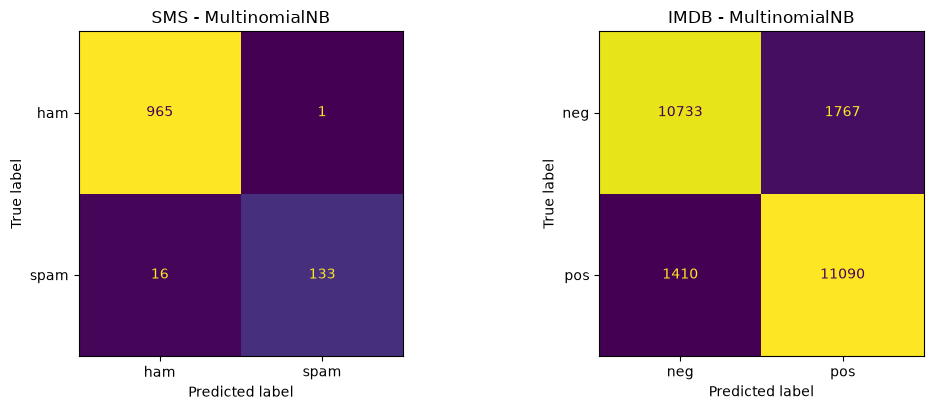

In [9]:
# Step 9 - final evaluation on the held-out test set, read once
RESULTS, Y_PRED, CV_SCORES = {}, {}, {}
RESULTS_AT_HALF = {}

for name, (Xtr, Xte, ytr, yte) in SPLITS.items():
    thr = BEST_THRESHOLD[name]

    # use the tuned alpha here, not the default 1.0 -- otherwise the numbers in
    # this cell would not describe the model that actually gets exported
    pipe = make_pipeline()
    pipe.set_params(nb__alpha=BEST_ALPHA[name])
    res, ypred = evaluate(pipe, Xtr, ytr, Xte, yte, TASKS[name]["positive"],
                          name="MultinomialNB", threshold=thr)
    RESULTS[name], Y_PRED[name] = res, ypred

    # the same model at the default 0.5 cut-off, for reference
    RESULTS_AT_HALF[name], _ = evaluate(make_pipeline().set_params(nb__alpha=BEST_ALPHA[name]),
                                        Xtr, ytr, Xte, yte, TASKS[name]["positive"],
                                        name="MultinomialNB", threshold=0.5)

    # 5-fold CV on train: generalising, or memorising?
    CV_SCORES[name] = cross_val_score(make_pipeline(), Xtr, ytr, cv=CV_FOLDS,
                                      scoring="f1_macro", n_jobs=1)

    print(f"\n########## {name.upper()} ##########")
    print(f"train/test      : {len(Xtr)} / {len(Xte)}")
    print(f"vocabulary size : {len(pipe['tfidf'].vocabulary_)}")
    print(f"best alpha      : {BEST_ALPHA[name]}   (tuned by 3-fold CV on train)")
    print(f"threshold       : {thr}   (tuned on validation, NOT on test)")
    print(f"train time      : {res['train_s']:.3f} s")
    print(f"inference       : {res['infer_ms']:.3f} ms / sample")
    print(f"model size      : {res['size_kb']:.1f} KB")
    print(f"5-fold macro-F1 : {CV_SCORES[name].mean():.4f} +/- {CV_SCORES[name].std():.4f}")
    print(f"\nclassification report at the tuned threshold "
          f"(positive class = {TASKS[name]['positive']!r}):")
    print(classification_report(yte, ypred, digits=4, zero_division=0))
    print("confusion matrix (rows=true, cols=pred), order "
          f"{sorted(set(yte))}:\n{confusion_matrix(yte, ypred, labels=sorted(set(yte)))}")
    print(f"F1 at threshold {thr} : {res['f1']:.4f}")
    print(f"F1 at threshold 0.5  : {RESULTS_AT_HALF[name]['f1']:.4f}")
    print(f"ROC-AUC              : {res['roc_auc']:.4f}")

# One panel per task, sized from the data rather than hard-coded, and saved to
# disk: docs/report.tex embeds this file, so without the save the report would
# reference an image that a notebook run never produced.
n_tasks = len(SPLITS)
fig, axes = plt.subplots(1, n_tasks, figsize=(5.5 * n_tasks, 4.2), squeeze=False)
for ax, name in zip(axes[0], SPLITS):
    ConfusionMatrixDisplay.from_predictions(
        SPLITS[name][3], Y_PRED[name], labels=sorted(set(SPLITS[name][3])),
        ax=ax, colorbar=False)
    ax.set_title(f"{name.upper()} - MultinomialNB")
fig.tight_layout()
fig_path = DOCS / "confusion_matrices.png"
fig.savefig(fig_path, dpi=150)
print(f"\nwrote {fig_path}")
plt.show()


## 10 - Ablation



In [10]:
# Step 10 - ablation: which preprocessing choice actually matters?
# `role` is a machine-readable flag: any report generated from this must use it,
# never the human-readable label, so it does not matter that the label here says
# [FINAL] while the library's says [SHIPPED].
ABLATION_CFG = [
    ("CountVectorizer (raw counts), unigram", "count", dict(ngram_range=(1, 1)), "variant"),
    ("TF-IDF, unigram",                       "tfidf", dict(ngram_range=(1, 1)), "variant"),
    ("TF-IDF, unigram + english stopwords",   "tfidf", dict(ngram_range=(1, 1), stop_words="english"), "variant"),
    ("TF-IDF, (1,2), keep negation  [FINAL]", "tfidf", dict(), "shipped"),
]

rows = []
for name, (Xtr, Xte, ytr, yte) in SPLITS.items():
    pos = TASKS[name]["positive"]
    for label, kind, override, role in ABLATION_CFG:
        params = dict(VEC_PARAMS)
        params.update(override)
        if kind == "count":
            # raw term counts: CountVectorizer has no TF-IDF weighting options
            for k in ("sublinear_tf",):
                params.pop(k, None)
            vec = CountVectorizer(**params)
        else:
            vec = TfidfVectorizer(**params)
        A, B = vec.fit_transform(Xtr), vec.transform(Xte)
        clf = MultinomialNB(alpha=BEST_ALPHA[name]).fit(A, ytr)
        pred = clf.predict(B)
        rows.append(dict(task=name, config=label, role=role, vocab=len(vec.vocabulary_),
                         accuracy=accuracy_score(yte, pred),
                         f1=f1_score(yte, pred, pos_label=pos, zero_division=0),
                         f1_macro=f1_score(yte, pred, average="macro", zero_division=0)))
        # Each config holds a full sparse matrix; free it before the next one so
        # the cell fits in a few GB of RAM.
        del A, B, vec, clf, pred
        gc.collect()

    # the minority class: SMS is 87% ham, so does class weighting rescue spam?
    vec = TfidfVectorizer(**VEC_PARAMS)
    A, B = vec.fit_transform(Xtr), vec.transform(Xte)
    sw = compute_sample_weight("balanced", ytr)
    clf = MultinomialNB(alpha=BEST_ALPHA[name]).fit(A, ytr, sample_weight=sw)
    pred = clf.predict(B)
    rows.append(dict(task=name, config="TF-IDF (1,2) + balanced class weights",
                     role="variant", vocab=len(vec.vocabulary_),
                     accuracy=accuracy_score(yte, pred),
                     f1=f1_score(yte, pred, pos_label=pos, zero_division=0),
                     f1_macro=f1_score(yte, pred, average="macro", zero_division=0)))
    del A, B, vec, clf, pred
    gc.collect()

# The library default alpha=1, on the shipped configuration. The report quotes
# these numbers to show what tuning bought, so measure them here rather than
# remembering them.
UNTUNED = {}
for name, (Xtr, Xte, ytr, yte) in SPLITS.items():
    pos = TASKS[name]["positive"]
    vec = TfidfVectorizer(**VEC_PARAMS)
    A, B = vec.fit_transform(Xtr), vec.transform(Xte)
    clf = MultinomialNB().fit(A, ytr)          # no argument == alpha=1.0
    pred = clf.predict(B)
    missed = (yte == pos) & (pred != pos)
    UNTUNED[name] = dict(
        alpha=float(clf.alpha), vocab=len(vec.vocabulary_),
        accuracy=accuracy_score(yte, pred),
        precision=precision_score(yte, pred, pos_label=pos, zero_division=0),
        recall=recall_score(yte, pred, pos_label=pos, zero_division=0),
        f1=f1_score(yte, pred, pos_label=pos, zero_division=0),
        f1_macro=f1_score(yte, pred, average="macro", zero_division=0),
        n_test=int(len(yte)), n_positive=int((yte == pos).sum()),
        n_missed=int(missed.sum()),
        overconfident_share=float((clf.predict_proba(B).max(axis=1) >= 0.99).mean()))
    del A, B, vec, clf, pred
    gc.collect()
print("=== untuned baseline (library default alpha=1) ===")
for name, r in UNTUNED.items():
    print(f"  {name:5s} f1={r['f1']:.4f} recall={r['recall']:.4f} "
          f"missed={r['n_missed']}/{r['n_positive']} "
          f"overconfident={r['overconfident_share']:.0%}")

ABLATION_DF = pd.DataFrame(rows)
print(ABLATION_DF.to_string(index=False, float_format=lambda v: f"{v:.4f}"))


=== untuned baseline (library default alpha=1) ===
  sms   f1=0.8494 recall=0.7383 missed=39/149 overconfident=51%
  imdb  f1=0.8696 recall=0.8534 missed=1832/12500 overconfident=1%
task                                config    role  vocab  accuracy     f1  f1_macro
 sms CountVectorizer (raw counts), unigram variant   3289    0.9830 0.9343    0.9622
 sms                       TF-IDF, unigram variant   3289    0.9821 0.9291    0.9594
 sms   TF-IDF, unigram + english stopwords variant   3045    0.9794 0.9199    0.9540
 sms TF-IDF, (1,2), keep negation  [FINAL] shipped  11373    0.9848 0.9399    0.9656
 sms TF-IDF (1,2) + balanced class weights variant  11373    0.9722 0.8970    0.9405
imdb CountVectorizer (raw counts), unigram variant  44213    0.8168 0.8042    0.8160
imdb                       TF-IDF, unigram variant  44213    0.8357 0.8263    0.8352
imdb   TF-IDF, unigram + english stopwords variant  43910    0.8369 0.8292    0.8366
imdb TF-IDF, (1,2), keep negation  [FINAL] shipped  5

## 11 - Benchmark against other classifiers
Compares Naive Bayes with BernoulliNB, ComplementNB, Logistic Regression, LinearSVC,
k-NN and a random forest, on an identical split and an identical vectoriser.



In [11]:
# Step 11 - benchmark against other classifiers (same split, same vectorizer)
BENCH_VEC = dict(VEC_PARAMS, max_features=20_000)   # trees densify the matrix

CANDIDATES = {
    "MultinomialNB":     lambda: MultinomialNB(alpha=1.0),
    "BernoulliNB":       lambda: BernoulliNB(alpha=1.0),
    "ComplementNB":      lambda: ComplementNB(alpha=1.0),
    "LogisticRegression": lambda: LogisticRegression(max_iter=1000, n_jobs=-1),
    "LinearSVC":         lambda: LinearSVC(dual="auto", max_iter=5000),
    "KNN (k=5)":         lambda: KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "RandomForest(50)":  lambda: RandomForestClassifier(n_estimators=50, n_jobs=-1,
                                                        random_state=SEED),
}
# Heavy models: only run on the small dataset, densifying 25,000 x 20,000 is too slow
HEAVY_ON_IMDB = {"KNN (k=5)", "RandomForest(50)"}
KNN_MAX_TEST = 3000

bench_rows = []
for name, (Xtr, Xte, ytr, yte) in SPLITS.items():
    pos = TASKS[name]["positive"]
    vec = TfidfVectorizer(**BENCH_VEC)
    A, B = vec.fit_transform(Xtr), vec.transform(Xte)
    print(f"\n[{name}] features={A.shape[1]}  density={A.nnz/(A.shape[0]*A.shape[1]):.4f}"
          f"  train={A.shape}  test={B.shape}")

    for mname, factory in CANDIDATES.items():
        if name == "imdb" and mname in HEAVY_ON_IMDB:
            bench_rows.append(dict(task=name, model=mname, note="skipped on IMDb (memory/runtime)"))
            print(f"  {mname:20s} SKIPPED on imdb")
            continue
        Bu, yu = B, yte
        if mname.startswith("KNN") and B.shape[0] > KNN_MAX_TEST:
            sel = np.random.RandomState(SEED).choice(B.shape[0], KNN_MAX_TEST, replace=False)
            Bu, yu = B[sel], yte.iloc[sel].to_numpy()
        try:
            est = factory()
            used_alpha, tune_s = "", 0.0
            if mname in ("MultinomialNB", "BernoulliNB", "ComplementNB"):
                # tune alpha for every NB variant, otherwise the comparison is
                # against an untuned baseline and the conclusion is wrong
                t0 = time.perf_counter()
                g = GridSearchCV(est, {"alpha": ALPHAS}, cv=3, scoring="f1_macro",
                                 n_jobs=1).fit(A, ytr)
                tune_s = time.perf_counter() - t0
                used_alpha = f"a={g.best_params_['alpha']:g}"
                best = g.best_params_
            else:
                best = {}
            # time ONE fit of the final hyper-parameters, so the train_s column
            # compares like with like (the grid search cost is reported separately)
            t0 = time.perf_counter()
            m = factory().set_params(**best).fit(A, ytr)
            fit_s = time.perf_counter() - t0
            t0 = time.perf_counter()
            pred = m.predict(Bu)
            pred_s = time.perf_counter() - t0
            p = list(m.classes_).index(pos)
            if hasattr(m, "predict_proba"):
                auc = roc_auc_score((yu == pos).astype(int), m.predict_proba(Bu)[:, p])
            else:
                auc = float("nan")
            row = dict(task=name, model=f"{mname} {used_alpha}".strip(),
                       fit_s=fit_s, tune_s=tune_s,
                       infer_ms=pred_s / len(yu) * 1000,
                       size_kb=model_size_kb(m),
                       accuracy=accuracy_score(yu, pred),
                       precision=precision_score(yu, pred, pos_label=pos, zero_division=0),
                       recall=recall_score(yu, pred, pos_label=pos, zero_division=0),
                       f1=f1_score(yu, pred, pos_label=pos, zero_division=0),
                       f1_macro=f1_score(yu, pred, average="macro", zero_division=0),
                       roc_auc=auc, note="")
            bench_rows.append(row)
            print(f"  {row['model']:28s} acc={row['accuracy']:.4f} f1={row['f1']:.4f} "
                  f"fit={fit_s:7.3f}s tune={tune_s:6.2f}s {row['size_kb']:8.1f}KB")
            del Bu, m, pred
            gc.collect()
        except Exception as e:
            bench_rows.append(dict(task=name, model=mname, note=f"failed: {type(e).__name__}: {e}"))
            print(f"  {mname:20s} FAILED {type(e).__name__}: {e}")
    del A, B, vec
    gc.collect()

# Single-call end-to-end latency: raw text in, label out, vectorisation included.
# This is what a Streamlit demo pays. A batch measurement that transforms once
# and predicts many times hides the vectorisation cost, which is shared by every
# model on the same vocabulary. These were hand-typed into the report before; they
# are measured now so the prose matches whatever machine runs the pipeline.
def _timed(fn, reps=200):
    fn()                                        # warm the code paths
    t0 = time.perf_counter()
    for _ in range(reps):
        fn()
    return (time.perf_counter() - t0) / reps * 1000


LATENCY = {}
for name, (Xtr, Xte, ytr, _yte) in SPLITS.items():
    vec = TfidfVectorizer(**VEC_PARAMS)
    A = vec.fit_transform(Xtr)
    message = str(np.asarray(Xte).ravel()[0])                  # a real message, not a best case
    row = {}
    for mname, est in (("MultinomialNB", MultinomialNB(alpha=BEST_ALPHA[name])),
                       ("LinearSVC", LinearSVC()),
                       ("LogisticRegression", LogisticRegression(max_iter=1000))):
        m = est.fit(A, ytr)
        row[f"{mname}_e2e_ms"] = _timed(lambda m=m, v=vec, t=message: m.predict(v.transform([t])))
    row["vectorise_ms"] = _timed(lambda v=vec, t=message: v.transform([t]))
    row["n_messages"] = 1
    LATENCY[name] = row
    del A, vec
    gc.collect()
print("=== single-call end-to-end latency (vectorisation included) ===")
for name, r in LATENCY.items():
    print(f"  {name:5s} NB={r['MultinomialNB_e2e_ms']:.3f}ms "
          f"SVC={r['LinearSVC_e2e_ms']:.3f}ms "
          f"LogReg={r['LogisticRegression_e2e_ms']:.3f}ms "
          f"vectorise={r['vectorise_ms']:.3f}ms")

BENCH_DF = pd.DataFrame(bench_rows)
BENCH_DF.to_csv(REPORTS / "benchmark_table.csv", index=False)
print()
print(BENCH_DF.to_string(index=False))



[sms] features=11373  density=0.0017  train=(4459, 11373)  test=(1115, 11373)


  MultinomialNB a=0.03         acc=0.9848 f1=0.9399 fit=  0.008s tune=  0.40s    356.2KB


  BernoulliNB a=0.001          acc=0.9848 f1=0.9399 fit=  0.009s tune=  0.44s    356.2KB


  ComplementNB a=0.001         acc=0.9785 f1=0.9195 fit=  0.008s tune=  0.39s    445.1KB


  LogisticRegression           acc=0.9695 f1=0.8712 fit=  4.009s tune=  0.00s     89.8KB
  LinearSVC                    acc=0.9848 f1=0.9412 fit=  0.016s tune=  0.00s     89.7KB


...

  BernoulliNB a=1              acc=0.8626 f1=0.8628 fit=  0.135s tune=  4.79s    625.8KB


  ComplementNB a=3             acc=0.8659 f1=0.8638 fit=  0.072s tune=  3.30s    782.1KB


  LogisticRegression           acc=0.9004 f1=0.9010 fit=  3.611s tune=  0.00s    157.2KB


  LinearSVC                    acc=0.8922 f1=0.8921 fit=  1.058s tune=  0.00s    157.1KB
  KNN (k=5)            SKIPPED on imdb
  RandomForest(50)     SKIPPED on imdb


=== single-call end-to-end latency (vectorisation included) ===
  sms   NB=0.769ms SVC=0.646ms LogReg=0.605ms vectorise=0.529ms
  imdb  NB=1.260ms SVC=0.847ms LogReg=1.184ms vectorise=0.948ms

task                model    fit_s   tune_s  infer_ms     size_kb  accuracy  precision   recall       f1  f1_macro  roc_auc                             note
 sms MultinomialNB a=0.03 0.007877 0.401812  0.000341  356.194336  0.984753   0.992537 0.892617 0.939929  0.965599 0.988870                                 
 sms  BernoulliNB a=0.001 0.008519 0.441718  0.000955  356.209961  0.984753   0.992537 0.892617 0.939929  0.965599 0.985028                                 
 sms ComplementNB a=0.001 0.007911 0.392709  0.000330  445.100586  0.978475   0.919463 0.919463 0.919463  0.953520 0.986994                                 
 sms   LogisticRegression 4.008759 0.000000  0.000430   89.842773  0.969507   1.000000 0.771812 0.871212  0.926959 0.991725                                 
 sms            Linear

## 12 - Improvement search


In [12]:
# Step 12 - improvement search: what else did we try, and why we did NOT ship it
# Keeping the negative results is deliberate: it shows the configuration was
# chosen by measurement, not by guessing.
# Variants are RANKED on the validation split (see cell 10); the test column is
# printed for information only and is not used to pick anything.
print("=== A. bigger vocabulary / richer n-grams ===")

VARIANTS = [
    ("(1,2)gram, max_features=50k  [SHIPPED]", dict(), True),
    ("(1,2)gram, max_features=100k", dict(max_features=100_000), False),
    ("(1,2)gram, no vocabulary cap", dict(max_features=None), False),
    ("(1,3)gram, max_features=100k", dict(ngram_range=(1, 3), max_features=100_000), False),
    ("min_df=1,   (1,2)gram, 100k", dict(min_df=1, max_features=100_000), False),
]
variant_rows = []
for name, (Xtr, Xte, ytr, yte) in SPLITS.items():
    pos = TASKS[name]["positive"]
    Xa, Xv, ya, yv = VAL_SPLIT[name]          # validation slice of TRAIN
    for label, over, is_shipped in VARIANTS:
        params = dict(VEC_PARAMS)
        params.update(over)
        vec = TfidfVectorizer(**params)
        A, Bv, Bt = vec.fit_transform(Xa), vec.transform(Xv), vec.transform(Xte)
        g = GridSearchCV(MultinomialNB(), {"alpha": ALPHAS}, cv=3,
                         scoring="f1_macro", n_jobs=1).fit(A, ya)
        m = g.best_estimator_
        variant_rows.append(dict(task=name, variant=label, is_shipped=is_shipped,
                                 vocab=len(vec.vocabulary_),
                                 alpha=g.best_params_["alpha"],
                                 f1_val=f1_score(yv, m.predict(Bv), pos_label=pos, zero_division=0),
                                 f1_test=f1_score(yte, m.predict(Bt), pos_label=pos, zero_division=0)))
        del A, Bv, Bt, vec, m
        gc.collect()
VARIANT_DF = pd.DataFrame(variant_rows)
print(VARIANT_DF.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
for name in TASKS:
    sub = VARIANT_DF[VARIANT_DF["task"] == name]
    best_val = sub.loc[sub["f1_val"].idxmax(), "variant"]
    shipped = sub.loc[sub["f1_test"].idxmax(), "variant"]
    print(f"[{name}] best on validation : {best_val}")
    print(f"[{name}] best on test      : {shipped}   <- only a coincidence check, not a choice")

print("\n=== B. probability calibration (the weakness flagged in the write-up) ===")
cal_rows = []
for name, (Xtr, Xte, ytr, yte) in SPLITS.items():
    pos = TASKS[name]["positive"]
    vec = TfidfVectorizer(**VEC_PARAMS)
    A, B = vec.fit_transform(Xtr), vec.transform(Xte)
    nb = MultinomialNB(alpha=BEST_ALPHA[name]).fit(A, ytr)
    cal = CalibratedClassifierCV(MultinomialNB(alpha=BEST_ALPHA[name]),
                                 cv=CV_FOLDS, method="sigmoid").fit(A, ytr)
    ybin = (yte == pos).astype(int).to_numpy()
    pi = list(nb.classes_).index(pos)
    cal_rows.append(dict(task=name,
                         brier_raw=brier_score_loss(ybin, nb.predict_proba(B)[:, pi]),
                         brier_cal=brier_score_loss(ybin, cal.predict_proba(B)[:, pi]),
                         f1_raw=f1_score(yte, nb.predict(B), pos_label=pos, zero_division=0),
                         f1_cal=f1_score(yte, cal.predict(B), pos_label=pos, zero_division=0)))
CAL_DF = pd.DataFrame(cal_rows)
print(CAL_DF.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

print("\n=== C. the threshold sweep itself (chosen on validation, in cell 10) ===")
print(THR_DF.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("\nF1-optimal threshold per task:", BEST_THRESHOLD)
print("This is a real advantage over LinearSVC, which cannot be tuned this way at all")
print("because it has no predict_proba.")


=== A. bigger vocabulary / richer n-grams ===


task                                variant  is_shipped  vocab  alpha  f1_val  f1_test
 sms (1,2)gram, max_features=50k  [SHIPPED]        True   9730 0.0030  0.9249   0.9187
 sms           (1,2)gram, max_features=100k       False   9730 0.0030  0.9249   0.9187
 sms           (1,2)gram, no vocabulary cap       False   9730 0.0030  0.9249   0.9187
 sms           (1,3)gram, max_features=100k       False  14074 0.0010  0.9240   0.9123
 sms            min_df=1,   (1,2)gram, 100k       False  36178 0.1000  0.9425   0.9291
imdb (1,2)gram, max_features=50k  [SHIPPED]        True  50000 0.1000  0.8819   0.8689
imdb           (1,2)gram, max_features=100k       False 100000 0.3000  0.8821   0.8685
imdb           (1,2)gram, no vocabulary cap       False 380721 0.3000  0.8848   0.8683
imdb           (1,3)gram, max_features=100k       False 100000 0.0030  0.8867   0.8791
imdb            min_df=1,   (1,2)gram, 100k       False 100000 0.3000  0.8818   0.8685
[sms] best on validation : min_df=1,   (1,2

task  brier_raw  brier_cal  f1_raw  f1_cal
 sms     0.0138     0.0146  0.9399  0.9362
imdb     0.1031     0.0918  0.8696  0.8730

=== C. the threshold sweep itself (chosen on validation, in cell 10) ===
task  threshold  precision  recall     f1
 sms     0.2000     0.9318  0.9111 0.9213
 sms     0.2250     0.9425  0.9111 0.9266
 sms     0.2500     0.9419  0.9000 0.9205
 sms     0.2750     0.9419  0.9000 0.9205
 sms     0.3000     0.9529  0.9000 0.9257
 sms     0.3250     0.9529  0.9000 0.9257
 sms     0.3500     0.9643  0.9000 0.9310
 sms     0.3750     0.9643  0.9000 0.9310
 sms     0.4000     0.9643  0.9000 0.9310
 sms     0.4250     0.9643  0.9000 0.9310
 sms     0.4500     0.9643  0.9000 0.9310
 sms     0.4750     0.9643  0.9000 0.9310
 sms     0.5000     0.9643  0.9000 0.9310
 sms     0.5250     0.9643  0.9000 0.9310
 sms     0.5500     0.9878  0.9000 0.9419
 sms     0.5750     0.9878  0.9000 0.9419
 sms     0.6000     0.9877  0.8889 0.9357
imdb     0.2000     0.6824  0.9899 0.8078

## 13 - Export model



In [ ]:
# Step 13 - export the model bundles for the UI (TV4) and the demo sentences
LABEL_MAP = {
    "sms":  {0: "Ham (legit message)", 1: "Spam"},
    "imdb": {0: "Negative", 1: "Positive"},
}

BUNDLES = {}
for name, (Xtr, Xte, ytr, yte) in SPLITS.items():
    pipe = make_pipeline()
    pipe.set_params(nb__alpha=BEST_ALPHA[name])
    pipe.fit(Xtr, ytr)
    bundle = {
        "task": name,
        "model": pipe,                       # Pipeline(TfidfVectorizer, MultinomialNB)
        "threshold": BEST_THRESHOLD[name],   # F1-optimal cut-off, see cell 13c
        "classes": list(pipe.classes_),
        "label_map": LABEL_MAP[name],
        "metrics": {k: RESULTS[name][k] for k in
                    ("accuracy", "precision", "recall", "f1", "f1_macro",
                     "roc_auc", "train_s", "infer_ms", "size_kb")},
        "meta": {
            "sklearn_version": sklearn.__version__,
            "trained_at": time.strftime("%Y-%m-%d %H:%M:%S"),
            "n_train": int(len(Xtr)),
            "n_test": int(len(Xte)),
            "n_features": int(len(pipe["tfidf"].vocabulary_)),
            "best_alpha": float(BEST_ALPHA[name]),
            "threshold": float(BEST_THRESHOLD[name]),
        },
    }
    path = MODELS / f"{name}_bundle.joblib"
    joblib.dump(bundle, path, compress=3)
    BUNDLES[name] = bundle
    m = bundle["meta"]
    print(f"[{name}] -> {path.name} ({path.stat().st_size/1024:.1f} KB)  "
          f"classes={bundle['classes']}  vocab={m['n_features']}  "
          f"alpha={m['best_alpha']}  threshold={m['threshold']}  F1={RESULTS[name]['f1']:.4f}")

    # The group plan also asks for the model and the vectoriser as two separate
    # .pkl files, so write those as well.
    p_model = MODELS / f"{name}_model.pkl"
    p_vec = MODELS / f"{name}_vectorizer.pkl"
    joblib.dump(pipe.named_steps["nb"], p_model, compress=3)
    joblib.dump(pipe.named_steps["tfidf"], p_vec, compress=3)
    print(f"[{name}] -> {p_model.name} ({p_model.stat().st_size/1024:.1f} KB), "
          f"{p_vec.name} ({p_vec.stat().st_size/1024:.1f} KB)")


## 14 - Demo sentences and hostile input



In [14]:
# Step 14 - demo sentences + edge-case robustness
DEMO = {
    "sms": [
        "Congratulations! You have won a FREE 1000 pound gift card. Text CLAIM to 80086 now!",
        "URGENT! Your account has been suspended. Verify your password at http://secure-bank-verify.com now",
        "Free entry into our weekly competition! Just reply YES to join.",
        "Hey are we still meeting for lunch tomorrow at that new place near the station?",
        "Can you pick up milk and bread on your way home? Thanks!",
        "Docu no. 4 received this morning, please confirm if the figures match our records.",
    ],
    "imdb": [
        "An absolute masterpiece from the director; the acting is flawless and I loved every minute of it.",
        "One of the best films I have seen this year. Brilliant script, stunning visuals, wonderful soundtrack.",
        "I did NOT like this film at all. It was a complete waste of two hours of my life.",
        "A dull, predictable mess. The plot made no sense and the dialogue was painful to sit through.",
        "The acting was fine but the story dragged in the middle and the ending felt rushed.",
        "Honestly one of the most boring films I have ever watched.",
    ],
}

lines = ["# Demo sentences for the live presentation.",
         "# Format: <typed text>  ||  <predicted label> (confidence, latency)",
         "# Predictions below were produced by actually running the models.",
         ""]
for task, texts in DEMO.items():
    b = BUNDLES[task]
    lines.append(f"--- {task} ---")
    for t in texts:
        t0 = time.perf_counter()
        proba = b["model"].predict_proba([clean_text(t)])[0]
        ms = (time.perf_counter() - t0) * 1000
        i = int(proba.argmax())
        lines.append(f"{t}  ||  {b['label_map'][i]} ({proba[i]:.4f}, {ms:.1f} ms)")
    lines.append("")

(DATA / "demo_samples.txt").write_text("\n".join(lines), encoding="utf-8")
print("\n".join(lines))

print("=== edge cases (must not crash on stage) ===")
EDGE = ["", "   ", "!!!???...", "a", "12345", "<br />", "\U0001f642\U0001f642", "X" * 5000]
for task, b in BUNDLES.items():
    for t in EDGE:
        try:
            print(f"  [{task}] {t[:18]!r:24s} -> {b['model'].predict([clean_text(t)])[0]}")
        except Exception as e:
            print(f"  [{task}] {t[:18]!r:24s} -> FAILED {type(e).__name__}: {e}")


# Demo sentences for the live presentation.
# Format: <typed text>  ||  <predicted label> (confidence, latency)
# Predictions below were produced by actually running the models.

--- sms ---
Congratulations! You have won a FREE 1000 pound gift card. Text CLAIM to 80086 now!  ||  Spam (0.9999, 1.4 ms)
URGENT! Your account has been suspended. Verify your password at http://secure-bank-verify.com now  ||  Spam (0.9878, 0.9 ms)
Free entry into our weekly competition! Just reply YES to join.  ||  Spam (1.0000, 0.9 ms)
Hey are we still meeting for lunch tomorrow at that new place near the station?  ||  Ham (legit message) (0.9999, 0.9 ms)
Can you pick up milk and bread on your way home? Thanks!  ||  Ham (legit message) (0.9998, 0.9 ms)
Docu no. 4 received this morning, please confirm if the figures match our records.  ||  Ham (legit message) (0.7709, 0.8 ms)

--- imdb ---
An absolute masterpiece from the director; the acting is flawless and I loved every minute of it.  ||  Positive (0.7499, 